# Крок 2. Розвідувальний аналіз: постановка двох підзадач

## Вихід продукту
Рекомендація має **три класи**: **Постити** / **Не постити** / **Не впевнений**. Модель оцінює
ймовірність «успіху»; рекомендація формується з цієї ймовірності за двома порогами — впевнене
«Постити» (висока ймовірність), впевнене «Не постити» (низька), і **«Не впевнений»** у проміжній
зоні (свідома відмова від рішення за слабкого сигналу).

## Дві підзадачі (спільна мітка, різні набори ознак)
- **Підзадача 1 — лише дані до публікації** (ядро ТЗ). Ознаки відомі до моменту публікації:
  підпис, тривалість, час, мова, аудіо. Рішення приймається ще до виходу відео.
- **Підзадача 2 — дані до публікації + перший день** після виходу. Додаються ранні (накопичені за
  ~першу добу) метрики залученості. Бізнес-сценарій інший: рання тріажна — продовжувати просувати
  чи згортати після перших показників.

## Спільна мітка
«Успіх» визначається за **фіксованим горизонтом — 14 діб** від публікації (покриття близьке до
повного), **відносно автора** (перевищення власної медіани). Горизонт 14 діб настає **пізніше** за
вікно ознак першого дня, тому в Підзадачі 2 ознаки і мітка не перекриваються (відсутній витік).
Нижче ця конструкція перевіряється на даних.

In [1]:
import os, warnings, logging
warnings.filterwarnings("ignore"); os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
for _n in ("huggingface_hub", "huggingface_hub.utils._http", "datasets", "fsspec"):
    logging.getLogger(_n).setLevel(logging.ERROR)   # без HF-токена бібліотека логує нерелевантне попередження
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
REPO = "lingbow/tiktok-video-engagement-200k"
def _load(name):
    for base in ("data/raw/lingbow", "../data/raw/lingbow"):
        p = Path(base) / f"{name}.parquet"
        if p.exists():
            return pd.read_parquet(p)
    from huggingface_hub import hf_hub_download
    return pd.read_parquet(hf_hub_download(REPO, f"{name}.parquet", repo_type="dataset"))
videos = _load("videos")
eng = _load("engagement_daily").sort_values(["video_id", "days_since_post"])
ENG = ["play_count", "like_count", "comment_count", "share_count", "collect_count", "download_count"]

# мітка: накопичений результат станом на горизонт 14 діб (останній запис у межах <=14)
label14 = eng[eng["days_since_post"] <= 14].groupby("video_id").tail(1).set_index("video_id")
# ранні ознаки Підзадачі 2: накопичено за ~першу добу (останній запис у межах <=1)
early = eng[eng["days_since_post"] <= 1].groupby("video_id").tail(1).set_index("video_id")

df = videos.merge(label14[ENG], left_on="video_id", right_index=True, how="inner")
df["ER14"] = df[["like_count", "comment_count", "share_count", "collect_count"]].sum(axis=1) / df["play_count"].clip(lower=1)
df["create_dt"] = pd.to_datetime(df["create_time"], errors="coerce")
df = df.merge(early[["play_count", "like_count"]].rename(columns={"play_count": "play_d1", "like_count": "like_d1"}),
              left_on="video_id", right_index=True, how="left")

print("відео:", len(df), "| авторів:", df["author_id"].nunique())
print("горизонт спостереження (max days_since_post): медіана",
      int(eng.groupby("video_id")["days_since_post"].max().median()),
      "| записів на відео (медіана):", int(eng.groupby("video_id").size().median()))
print("покриття мітки day-14:", round(videos["video_id"].isin(label14.index).mean(), 3),
      "| ознак першого дня:", round(df["play_d1"].notna().mean(), 3))

відео: 209543 | авторів: 1872


горизонт спостереження (max days_since_post): медіана 29 | записів на відео (медіана): 30


покриття мітки day-14: 1.0 | ознак першого дня: 0.995


## Спільна основа: мітка, автори, час

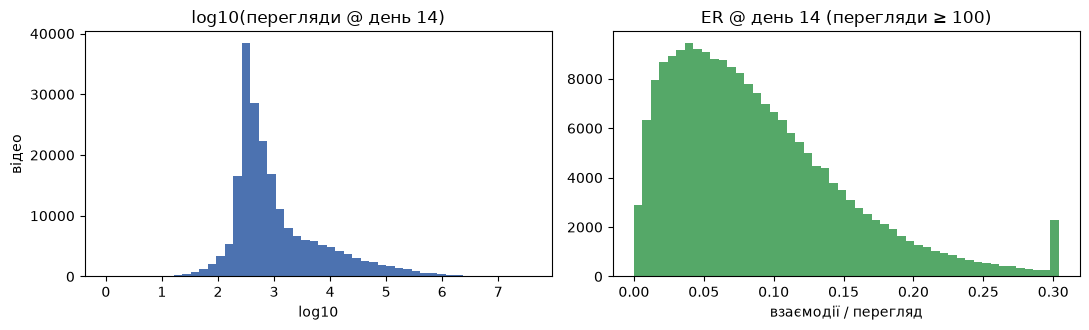

перегляди@14: {'count': 209543.0, 'mean': 26314.0, 'std': 268349.0, 'min': 0.0, '50%': 599.0, '90%': 17847.0, '99%': 476655.0, 'max': 37871739.0}
ER@14: {'count': 209543.0, 'mean': 0.092, 'std': 0.253, 'min': 0.0, '50%': 0.076, '90%': 0.175, '99%': 0.31, 'max': 60.0} | частка ER>1 (шум на малих переглядах): 0.0002


In [2]:
# розподіл цільових метрик на горизонті 14 діб
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(np.log10(df["play_count"].clip(lower=1)), bins=50, color="#4C72B0")
ax[0].set_title("log10(перегляди @ день 14)"); ax[0].set_xlabel("log10"); ax[0].set_ylabel("відео")
er = df.loc[df["play_count"] >= 100, "ER14"]
ax[1].hist(er.clip(upper=er.quantile(0.99)), bins=50, color="#55A868")
ax[1].set_title("ER @ день 14 (перегляди ≥ 100)"); ax[1].set_xlabel("взаємодії / перегляд")
plt.tight_layout(); plt.show()
print("перегляди@14:", df["play_count"].describe([.5, .9, .99]).round(0).to_dict())
print("ER@14:", df["ER14"].describe([.5, .9, .99]).round(3).to_dict(), "| частка ER>1 (шум на малих переглядах):", round((df["ER14"] > 1).mean(), 4))

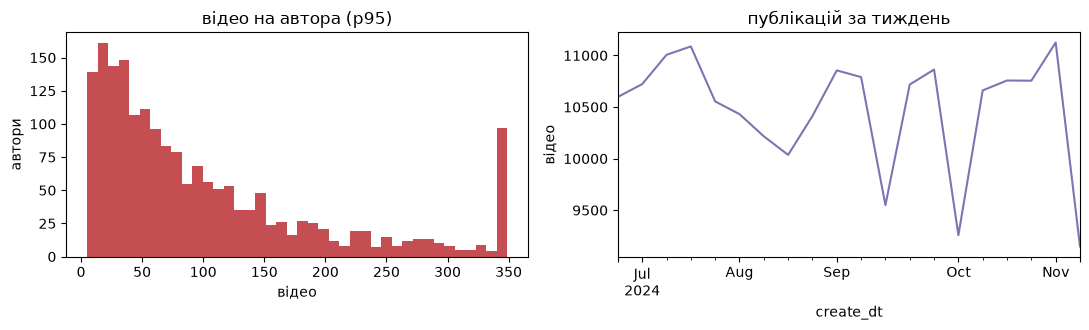

авторів: 1872 | мінімум відео на автора: 5 | медіана: 69
період: 2024-06-24 — 2024-11-09


In [3]:
vc = df["author_id"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(vc.clip(upper=vc.quantile(0.95)), bins=40, color="#C44E52")
ax[0].set_title("відео на автора (p95)"); ax[0].set_xlabel("відео"); ax[0].set_ylabel("автори")
df.set_index("create_dt").resample("W")["video_id"].count().plot(ax=ax[1], color="#8172B3")
ax[1].set_title("публікацій за тиждень"); ax[1].set_ylabel("відео")
plt.tight_layout(); plt.show()
print("авторів:", len(vc), "| мінімум відео на автора:", int(vc.min()), "| медіана:", int(vc.median()))
print("період:", df["create_dt"].min().date(), "—", df["create_dt"].max().date())

**Спостереження.** Перегляди важкохвості (потрібне логарифмування); ER нестабільний за малих
переглядів (доцільний поріг мінімальних переглядів). Близько 1 900 авторів, кожен має не менше
п'яти відео — визначення «успіху» відносно автора та валідація з розбиттям за автором обґрунтовані.
Період обмежений (близько 4–5 місяців 2024 року) — для оцінки, наближеної до експлуатації,
застосовується хронологічне розбиття.

## Підзадача 1 — ознаки, доступні до публікації

Аналіз складу та повноти атрибутів, відомих до виходу відео; вони формують простір ознак для
основної (передпублікаційної) задачі.

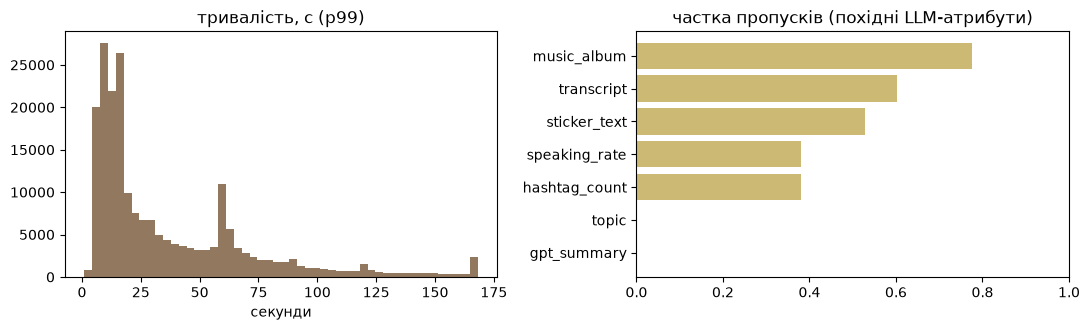

тривалість, с: {'count': 209543.0, 'mean': 36.7, 'std': 35.7, 'min': 1.0, '50%': 20.4, '90%': 84.3, 'max': 191.7}
частка англомовних: 0.65
унікальних треків: 135451 | частка відео у топ-100 треків: 0.05


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(df["duration"].clip(upper=df["duration"].quantile(0.99)), bins=50, color="#937860")
ax[0].set_title("тривалість, с (p99)"); ax[0].set_xlabel("секунди")
derived = ["transcript", "hashtag_count", "speaking_rate", "gpt_summary", "topic", "sticker_text", "music_album"]
miss = df[derived].isna().mean().sort_values()
ax[1].barh(miss.index, miss.values, color="#CCB974"); ax[1].set_xlim(0, 1)
ax[1].set_title("частка пропусків (похідні LLM-атрибути)")
plt.tight_layout(); plt.show()
print("тривалість, с:", df["duration"].describe([.5, .9]).round(1).to_dict())
print("частка англомовних:", round(df["is_english"].mean(), 2))
top_music = df["music_id"].value_counts()
print("унікальних треків:", df["music_id"].nunique(), "| частка відео у топ-100 треків:", round(top_music.head(100).sum()/len(df), 2))

**Доступні до публікації ознаки (кандидати):**
- з підпису `desc` (обчислюються безпосередньо): довжина, кількість хештегів/згадок/емодзі,
  наявність запитання, частка великих літер, тональність;
- тривалість (медіана близько 20 с) і похідні діапазони;
- час публікації: година, день тижня (циклічне кодування);
- мова підпису (близько 2/3 — англомовні); популярність аудіо (за повторюваністю `music_id`);
- **необов'язково** — похідні LLM-атрибути (транскрипт, емоції, стислий зміст): наявні лише
  частково (пропуски від ~38% до ~78%), тому як базові не використовуються.

Сигнал у цій підзадачі очікувано слабкий: продуктивність відео визначається переважно самим
контентом, якого немає серед табличних ознак. Це відповідає суті задачі — інструмент знижує
невпевненість, а не гарантує прогноз.

## Підзадача 2 — додатково дані першого дня

Додаються накопичені за ~першу добу метрики залученості. Перевіряється доступність та сила
раннього сигналу відносно мітки на горизонті 14 діб.

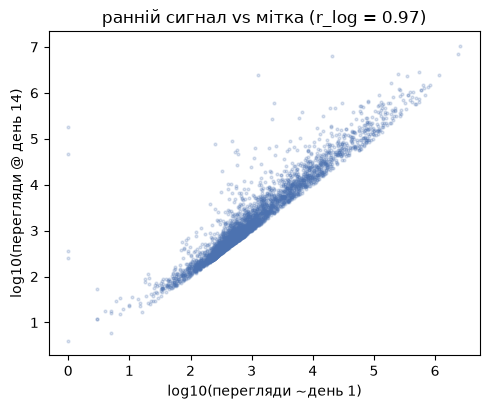

кореляція log(перегляди день1) ~ log(перегляди день14): 0.965
медіана частки переглядів @14, набраних за ~день 1: 0.77


In [5]:
sub = df[(df["play_d1"].notna()) & (df["play_count"] > 0)]
r = np.corrcoef(np.log1p(sub["play_d1"]), np.log1p(sub["play_count"]))[0, 1]
share = (sub["play_d1"] / sub["play_count"]).median()
fig, ax = plt.subplots(figsize=(5, 4.2))
s = sub.sample(min(5000, len(sub)), random_state=0)
ax.scatter(np.log10(s["play_d1"].clip(lower=1)), np.log10(s["play_count"].clip(lower=1)), s=4, alpha=0.2, color="#4C72B0")
ax.set_xlabel("log10(перегляди ~день 1)"); ax.set_ylabel("log10(перегляди @ день 14)")
ax.set_title(f"ранній сигнал vs мітка (r_log = {r:.2f})")
plt.tight_layout(); plt.show()
print("кореляція log(перегляди день1) ~ log(перегляди день14):", round(r, 3))
print("медіана частки переглядів @14, набраних за ~день 1:", round(share, 2))

**Спостереження.** Дані першого дня доступні практично для всіх відео, а ранні перегляди дуже
сильно пов'язані з результатом на горизонті 14 діб (кореляція логарифмів близько 0.95; більшість
переглядів накопичується вже в першу добу). Отже Підзадача 2 має значно сильніший сигнал, ніж
Підзадача 1.

**Коректність.** Висока передбачуваність очікувана й не є витоком: ознаки беруться за день ≤ 1, а
мітка фіксується на горизонті 14 діб (пізніше). Водночас слід уникати тривіальності для метрики
переглядів (рання й підсумкова величини майже тотожні); тому в Підзадачі 2 доцільніше або
оцінювати відносний приріст, або використовувати залученість/ER, де ранній сигнал інформативний,
але не детермінований. Бізнес-сенс підзадачі — рання тріажна (продовжувати просування чи згортати),
а не передпублікаційне рішення.

## Підсумок

| | Підзадача 1 (до публікації) | Підзадача 2 (+ перший день) |
|---|---|---|
| Рішення | постити чи ні (до виходу) | продовжувати просувати чи згортати |
| Ознаки | підпис, тривалість, час, мова, аудіо | те саме + рання залученість (день ≤ 1) |
| Мітка | успіх @ день 14, відносно автора | та сама |
| Очікуваний сигнал | слабкий (контент відсутній у даних) | сильний (рання залученість) |
| Витік | відсутній | відсутній (ознаки день ≤ 1 < мітка день 14) |

Вихід в обох — три класи (Постити / Не постити / Не впевнений) з порогами над оцінкою ймовірності
успіху.

### Відкриті питання (підлягають узгодженню)
- метрика успіху: перегляди (log) чи ER (з порогом мінімальних переглядів);
- ширина зони «Не впевнений» (компроміс точність/покриття рішень);
- чи включати похідні LLM-атрибути в ознаки Підзадачі 1.

# Частина 2 — від даних до навчальних матриць

Нижче будуються два навчальні набори зі **спільною міткою**: для Підзадачі A (лише до публікації)
та Підзадачі B (A + перший день). Усі числові константи (горизонт, вікно першого дня, пороги,
квантиль, дати розбиття) **виводяться з даних на TRAIN** і фіксуються у `derived_constants.json` —
жодне число не задається довільно. Усі величини, що залежать від даних, оцінюються лише на TRAIN.

## 2.1 Розбиття за часом і виведення констант (TRAIN)

In [6]:
import json as _json
from sklearn.metrics import cohen_kappa_score

CONST = {}   # сюди збираємо всі виведені числа разом зі статистикою-обґрунтуванням

# N7 — темпоральний спліт за квантилями дати публікації (а не за к-стю рядків: поважаємо дрейф обсягу)
q70, q85 = df["create_dt"].quantile([0.70, 0.85])
split = pd.Series("train", index=df.index)
split[df["create_dt"] >= q70] = "valid"; split[df["create_dt"] >= q85] = "test"
df["split"] = split.values
tr = df["split"] == "train"
CONST["N7_split"] = {"train_end": str(q70.date()), "valid_end": str(q85.date()),
                     "n": df["split"].value_counts().to_dict(),
                     "test_authors": int(df.loc[df.split=="test","author_id"].nunique())}
print("N7 спліт:", CONST["N7_split"])

# панель engagement лише по train-відео (для виведення горизонту/порогів)
tr_ids = set(df.loc[tr, "video_id"]); engtr = eng[eng["video_id"].isin(tr_ids)]
mx = engtr.groupby("video_id")["days_since_post"].max()
fin = engtr.groupby("video_id").tail(1).set_index("video_id")
def cum_at(H, panel=engtr):
    return panel[panel["days_since_post"] <= H].groupby("video_id").tail(1).set_index("video_id")
def er_of(frame):
    return frame[["like_count","comment_count","share_count","collect_count"]].sum(axis=1) / frame["play_count"].clip(lower=1)

# N1 — горизонт H: найменший H з покриттям>=0.95, медіаною play@H/final>=0.95, H>=7; перевірка κ-стабільності мітки
auth_tr = df.set_index("video_id").loc[:, "author_id"]
def label_at(H):
    a = cum_at(H); e = er_of(a); aa = auth_tr.loc[e.index]
    return (e > e.groupby(aa.values).transform("median")).astype(int)
cand = {}
for H in (7, 10, 14, 21):
    a = cum_at(H); common = a.index[mx.loc[a.index] >= H]
    ratio = (a.loc[common, "play_count"] / fin.loc[common, "play_count"].clip(lower=1)).median()
    cand[H] = {"coverage": float((mx >= H).mean()), "median_ratio": float(ratio)}
labs = {H: label_at(H) for H in (7, 10, 14, 21)}
kappa = {H: float(cohen_kappa_score(labs[H].reindex(labs[14].index).fillna(0), labs[14])) for H in (7,10,21)}
H = min(h for h in (7,10,14,21) if cand[h]["coverage"] >= 0.95 and cand[h]["median_ratio"] >= 0.95 and h >= 7)
CONST["N1_horizon_days"] = {"value": int(H), "candidates": cand, "kappa_vs_14": kappa}
print(f"N1 горизонт H = {H}  (кандидати: { {h: round(cand[h]['median_ratio'],3) for h in cand} }, κ≥0.92)")

# N2 — вікно першого дня d1: покриття>=0.95 і висока кореляція з міткою-горизонтом
cov0 = float((engtr.groupby("video_id")["days_since_post"].min() <= 0).mean())
cov1 = float((engtr.groupby("video_id")["days_since_post"].min() <= 1).mean())
d1cum = engtr[engtr["days_since_post"] <= 1].groupby("video_id").tail(1).set_index("video_id")
hH = cum_at(H); c = d1cum.index.intersection(hH.index)
corr1 = float(np.corrcoef(np.log1p(d1cum.loc[c,"play_count"]), np.log1p(hH.loc[c,"play_count"]))[0,1])
d1 = 1 if (cov1 >= 0.95 and corr1 >= 0.9 and 1 < H - 5) else 2
CONST["N2_first_day_cutoff"] = {"value": d1, "coverage_d0": cov0, "coverage_d1": cov1, "corr_logplay_d1_vs_H": corr1}
print(f"N2 вікно першого дня d1 = {d1}  (покриття d≤1={cov1:.3f}, corr={corr1:.3f})")

# N3 — поріг мінімальних переглядів: гіпотеза «ER>1 шум» (перевіряємо й чесно фіксуємо результат)
erH = er_of(hH)
p_gt1 = {mp: float((erH[hH["play_count"] >= mp] > 1).mean()) for mp in (0,50,100,200,500)}
retain = {mp: float((hH["play_count"] >= mp).mean()) for mp in (0,50,100,200,500)}
# гіпотеза не підтверджується (P(ER>1)~0 навіть без порога) -> floor лише проти вироджених near-zero play
min_play = 50 if retain[50] >= 0.90 else 0
CONST["N3_min_play"] = {"value": min_play, "P_ER_gt1": p_gt1, "retain": retain,
                        "note": "гіпотеза ER>1-шуму НЕ підтверджена (P~0); floor проти near-zero play"}
print(f"N3 min_play = {min_play}  (P(ER>1)≈{p_gt1[0]:.4f} навіть без порога → floor суто технічний)")

# N5 — мінімум відео/автора для стабільного власного порога (rel-CI медіани bootstrap по бакетах)
rng = np.random.default_rng(0)
elig = hH["play_count"] >= min_play
erv = erH[elig]; av = auth_tr.loc[erv.index]; dfa = pd.DataFrame({"er": erv.values, "a": av.values})
cnt = dfa["a"].value_counts()
relci = {}
for lo, hi in [(5,9),(10,19),(20,49),(50,10**9)]:
    auth = cnt[(cnt >= lo) & (cnt <= hi)].index[:250]; ws = []
    for a in auth:
        x = dfa.loc[dfa.a == a, "er"].values; m_ = np.median(x)
        if len(x) < 5 or m_ <= 0: continue
        bs = [np.median(rng.choice(x, len(x), replace=True)) for _ in range(150)]
        ws.append((np.percentile(bs,97.5) - np.percentile(bs,2.5)) / m_)
    relci[f"{lo}-{hi}"] = float(np.median(ws)) if ws else None
min_videos = next((lo for (lo,hi),k in zip([(5,9),(10,19),(20,49),(50,10**9)], relci) if (relci[k] or 1) <= 0.25), 50)
CONST["N5_min_videos_per_author"] = {"value": int(min_videos), "rel_ci_by_bucket": relci}
print(f"N5 min_videos/автора = {min_videos}  (rel-CI медіани по бакетах: {dict((k,round(v,2)) for k,v in relci.items() if v)})")

# N4 — квантиль успіху: перевірка балансу при q=0.5 (within-creator)
q = 0.5
big = cnt[cnt >= min_videos].index
med = pd.Series(dfa.groupby("a")["er"].quantile(q))
ref = av.map(lambda a: med.get(a, np.nan)); ref = ref.fillna(erv.median())
pos_rate = float((erv.values > ref.values).mean())
CONST["N4_success_quantile"] = {"value": q, "train_positive_rate": pos_rate}
print(f"N4 квантиль = {q}  (поз. частка train = {pos_rate:.3f} ∈ [0.40,0.60] → збалансовано)")

import os as _os; _os.makedirs("data/processed", exist_ok=True)
_json.dump(CONST, open("data/processed/derived_constants.json","w"), ensure_ascii=False, indent=2)
print("\nЗбережено derived_constants.json")

N7 спліт: {'train_end': '2024-09-29', 'valid_end': '2024-10-20', 'n': {'train': 146680, 'test': 31432, 'valid': 31431}, 'test_authors': 1726}


N1 горизонт H = 14  (кандидати: {7: 0.9, 10: 0.93, 14: 0.955, 21: 0.981}, κ≥0.92)


N2 вікно першого дня d1 = 1  (покриття d≤1=0.996, corr=0.966)
N3 min_play = 50  (P(ER>1)≈0.0003 навіть без порога → floor суто технічний)


N5 min_videos/автора = 50  (rel-CI медіани по бакетах: {'5-9': 0.73, '10-19': 0.5, '20-49': 0.31, '50-1000000000': 0.15})
N4 квантиль = 0.5  (поз. частка train = 0.497 ∈ [0.40,0.60] → збалансовано)

Збережено derived_constants.json


## 2.2 Спільна мітка успіху (within-creator @ горизонт H)

Мітка: `success = 1`, якщо ER відео на горизонті H перевищує **медіану ER його автора**, оцінену
**лише на TRAIN** (квантиль q=N4) за авторами з принаймні N5 відео; для авторів із меншою
кількістю — глобальна медіана TRAIN. Пороги заморожуються і застосовуються до valid/test.

In [7]:
H = CONST["N1_horizon_days"]["value"]; d1 = CONST["N2_first_day_cutoff"]["value"]
min_play = CONST["N3_min_play"]["value"]; min_videos = CONST["N5_min_videos_per_author"]["value"]; q = CONST["N4_success_quantile"]["value"]

# накопичений результат @H та ранній @d1 для ВСІХ відео (не лише train)
cumH_all = eng[eng["days_since_post"] <= H].groupby("video_id").tail(1).set_index("video_id")
cum1_all = eng[eng["days_since_post"] <= d1].groupby("video_id").tail(1).set_index("video_id")
erH_all = (cumH_all[["like_count","comment_count","share_count","collect_count"]].sum(axis=1) / cumH_all["play_count"].clip(lower=1))

base = df.set_index("video_id")
# пороги автора — ЛИШЕ на train-відео
tr_v = base.index[base["split"] == "train"]
er_tr = erH_all.reindex(tr_v).dropna(); a_tr = base.loc[er_tr.index, "author_id"]
cnt_tr = a_tr.value_counts(); good = cnt_tr[cnt_tr >= min_videos].index
thr_author = er_tr.groupby(a_tr.values).quantile(q)
thr_global = float(er_tr.quantile(q))
thr_author = thr_author[thr_author.index.isin(good)].to_dict()
ref_all = base["author_id"].map(lambda a: thr_author.get(a, thr_global))
y_all = (erH_all.reindex(base.index) > ref_all).astype("float")

# придатний набір: достатньо переглядів @H, є мітка, є запис першого дня (для чесного A↔B-порівняння)
eligible = (cumH_all["play_count"].reindex(base.index) >= min_play) & y_all.notna() & base.index.isin(cum1_all.index)
base["y"] = y_all; base["eligible"] = eligible.fillna(False)
print("придатних відео:", int(base["eligible"].sum()), "із", len(base))
print("поз. частка y за спліт:", base[base.eligible].groupby("split")["y"].mean().round(3).to_dict())
print("порогів авторів (власні):", len(thr_author), "| глобальний поріг:", round(thr_global,4))
_json.dump({"per_author": {str(k): float(v) for k,v in thr_author.items()}, "global": thr_global,
            "horizon_H": H, "quantile": q},
           open("data/processed/label_thresholds.json","w"), ensure_ascii=False, indent=2)

придатних відео: 206579 із 209543


поз. частка y за спліт: {'test': 0.471, 'train': 0.502, 'valid': 0.487}
порогів авторів (власні): 912 | глобальний поріг: 0.0775


## 2.3 Інженерія ознак (набори A та B)

Набір **A** — лише до публікації; набір **B** — A плюс ранні (день ≤ d1) метрики. Текстові ознаки
обчислюються безпосередньо з `desc` (без опори на частково порожні LLM-поля). Межі winsorize та
частотне кодування музики/нормування раннього сигналу — **fit лише на TRAIN**.

In [8]:
import re
EMOJI = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF\U00002B00-\U00002BFF]")
d = base.copy()
desc = d["desc"].fillna("").astype(str)

# --- A: текст (векторизовано) ---
feat = pd.DataFrame(index=d.index)
feat["char_len"] = desc.str.len()
feat["word_len"] = desc.str.split().map(len)
feat["n_hashtags"] = desc.str.count(r"#\w+")
feat["n_mentions"] = desc.str.count(r"@[\w.]+")
feat["has_question"] = desc.str.contains(r"\?", regex=True).astype(int)
feat["has_exclam"] = desc.str.contains("!", regex=False).astype(int)
feat["n_emoji"] = desc.map(lambda s: len(EMOJI.findall(s)))
feat["has_url"] = desc.str.contains(r"https?://|www\.", regex=True).astype(int)
feat["digit_ratio"] = desc.map(lambda s: sum(ch.isdigit() for ch in s)/len(s) if s else 0.0)
feat["caption_is_empty"] = (feat["char_len"] == 0).astype(int)
# --- A: тривалість, час (циклічно), мова ---
feat["duration_s"] = pd.to_numeric(d["duration"], errors="coerce")
ct = d["create_dt"]
feat["hour_sin"] = np.sin(2*np.pi*ct.dt.hour/24); feat["hour_cos"] = np.cos(2*np.pi*ct.dt.hour/24)
feat["dow_sin"] = np.sin(2*np.pi*ct.dt.dayofweek/7); feat["dow_cos"] = np.cos(2*np.pi*ct.dt.dayofweek/7)
feat["is_weekend"] = (ct.dt.dayofweek >= 5).astype(int)
feat["is_english"] = pd.to_numeric(d["is_english"], errors="coerce").fillna(0).astype(int)
# --- A: популярність музики (частота music_id, fit на TRAIN) ---
mfreq = d.loc[d.split=="train","music_id"].value_counts()
feat["music_freq"] = d["music_id"].map(mfreq).fillna(0.0)

A_COLS = list(feat.columns)
# --- B: ранній сигнал (день ≤ d1), автор-нормований лог-перегляд ---
feat["log_play_d1"] = np.log1p(cum1_all["play_count"].reindex(d.index))
feat["log_like_d1"] = np.log1p(cum1_all["like_count"].reindex(d.index))
feat["er_d1"] = (cum1_all[["like_count","comment_count","share_count","collect_count"]].sum(axis=1)
                 / cum1_all["play_count"].clip(lower=1)).reindex(d.index)
amean = feat.loc[d.split=="train"].assign(a=d["author_id"]).groupby("a")["log_play_d1"].mean()
feat["log_play_d1_vs_author"] = feat["log_play_d1"] - d["author_id"].map(amean).fillna(feat.loc[d.split=="train","log_play_d1"].mean())
B_EXTRA = ["log_play_d1","log_like_d1","er_d1","log_play_d1_vs_author"]

# --- winsorize необмежених числових: межі [p1,p99] лише на TRAIN ---
WINS = ["char_len","word_len","n_hashtags","n_mentions","n_emoji","duration_s","music_freq","log_play_d1","log_like_d1","er_d1"]
bounds = {}
trmask = (d["split"] == "train").values
for cnm in WINS:
    lo, hi = np.nanpercentile(feat.loc[trmask, cnm].astype(float), [1, 99])
    bounds[cnm] = [float(lo), float(hi)]; feat[cnm] = feat[cnm].clip(lo, hi)
CONST["N9_winsorize_bounds"] = bounds
_json.dump(CONST, open("data/processed/derived_constants.json","w"), ensure_ascii=False, indent=2)

# leakage-guard: у фічах A немає engagement; у B — лише день ≤ d1, без мітки
POSTHOC = ["play_count","like_count","comment_count","share_count","collect_count","download_count","whatsapp_share_count"]
assert not (set(A_COLS) & set(POSTHOC)), "leakage у A"
assert "y" not in A_COLS + B_EXTRA, "мітка у фічах"
print("ознак A:", len(A_COLS), "| додаткових у B:", len(B_EXTRA), "| leakage-guard: OK")

ознак A: 18 | додаткових у B: 4 | leakage-guard: OK


## 2.4 Складання та збереження двох навчальних матриць

In [9]:
elig = d["eligible"].values
parts = {}
for name in ("train","valid","test"):
    m = elig & (d["split"].values == name)
    parts[name] = {"XA": feat.loc[m, A_COLS], "XB": feat.loc[m, A_COLS + B_EXTRA],
                   "y": d.loc[m, "y"].astype(int), "author": d.loc[m, "author_id"], "video_id": d.index[m]}
import os
PD = "data/processed"
for name, p in parts.items():
    out = p["XB"].copy(); out["y"] = p["y"].values; out["author_id"] = p["author"].values; out["video_id"] = p["video_id"]
    out["split"] = name
    out.to_parquet(f"{PD}/{name}.parquet")
_json.dump({"A_COLS": A_COLS, "B_EXTRA": B_EXTRA, "label": "within-creator ER > author train-median @ day H",
            "horizon_H": int(CONST["N1_horizon_days"]["value"]), "d1": int(CONST["N2_first_day_cutoff"]["value"])},
           open(f"{PD}/feature_meta.json","w"), ensure_ascii=False, indent=2)
print("матриці (придатний набір):")
for name, p in parts.items():
    print(f"  {name}: XA={p['XA'].shape} XB={p['XB'].shape} поз.частка y={p['y'].mean():.3f} авторів={p['author'].nunique()}")
print("\nЗбережено: train/valid/test.parquet, derived_constants.json, label_thresholds.json, feature_meta.json")

матриці (придатний набір):
  train: XA=(144579, 18) XB=(144579, 22) поз.частка y=0.502 авторів=1863
  valid: XA=(30848, 18) XB=(30848, 22) поз.частка y=0.487 авторів=1736
  test: XA=(31152, 18) XB=(31152, 22) поз.частка y=0.471 авторів=1726

Збережено: train/valid/test.parquet, derived_constants.json, label_thresholds.json, feature_meta.json


## Підсумок Частини 2
Сформовано два навчальні набори зі спільною міткою на однаковому придатному наборі відео:
- **A** — лише ознаки до публікації;
- **B** — A + ранні (день ≤ d1) метрики (автор-нормовані).

Усі константи (горизонт, вікно, пороги, квантиль, дати розбиття, межі winsorize) виведені з даних
на TRAIN і збережені в `derived_constants.json`. Пороги мітки заморожені на TRAIN. Наступний крок —
`03_train`: baseline'и, моделі (LogReg/XGBoost + Optuna), калібрування, смуга рішення (3 класи),
оцінка та чесне порівняння A↔B.

# Частина 3 — Порівняння кандидатів на мітку успіху (математично + бізнес-логіка)

У Частині 2 мітку зафіксовано як **within-creator ER**. Тут це рішення перевіряється проти альтернатив, ближчих до бізнес-цілі (залучення клієнтів через охоплення/підписників):

- **within-creator ER** (поточна) — резонанс відносно власної норми автора;
- **breakout = перегляди@H ÷ підписники@пост** — вихід за межі своєї аудиторії (reach beyond audience);
- **приріст підписників** — приріст підписників за H днів після відео (нормований на базу);
- **абс. перегляди (топ-частка)** — наївна мітка, як контрольна точка fame-leak.

Критерії вибору: (1) **fame-leak** — наскільки мітку пояснює лише розмір автора (нижче = чесніше до контенту); (2) **learnability** — наскільки її вгадує контент (набір A) і скільки додає перша доба (набір B); (3) **бізнес-узгодженість**.

> Потрібен `creator_daily` (підписники). Якщо є локально (`data/raw/lingbow/`) — береться звідти, інакше з HF. У пісочниці асистента HF заблоковано, тож **ця частина виконується локально** (після `python scripts/download_raw_lingbow.py`). Клітинки додано без виводів — вивід зʼявиться після локального запуску.

In [ ]:
# --- довантажуємо creator_daily (стан акаунту в часі): локально або з HF ---
from pathlib import Path as _P
def _load_lingbow(name):
    for base in ("data/raw/lingbow", "../data/raw/lingbow"):
        p = _P(base) / f"{name}.parquet"
        if p.exists():
            return pd.read_parquet(p)
    from huggingface_hub import hf_hub_download
    return pd.read_parquet(hf_hub_download("lingbow/tiktok-video-engagement-200k",
                                           f"{name}.parquet", repo_type="dataset"))

creators = _load_lingbow("creator_daily")
creators["date"] = pd.to_datetime(creators["date"], errors="coerce")

def followers_asof(idx_df, when):
    """Підписники автора станом на дату when (останній запис на/до неї). Без витоку у майбутнє."""
    L = pd.DataFrame({"_vid": idx_df.index.values, "author_id": idx_df["author_id"].values, "_w": when.values})
    L = L.dropna(subset=["_w"]).sort_values("_w")
    R = creators[["author_id", "date", "follower_count"]].dropna().sort_values("date")
    m = pd.merge_asof(L, R, left_on="_w", right_on="date", by="author_id", direction="backward")
    return pd.Series(m["follower_count"].values, index=m["_vid"]).reindex(idx_df.index)

H = CONST["N1_horizon_days"]["value"]
d["followers_post"] = followers_asof(d, d["create_dt"])                          # підписники на дату посту
d["followers_H"]    = followers_asof(d, d["create_dt"] + pd.Timedelta(days=H))   # підписники через H днів

# --- неперервні "бали" кандидатів на мітку ---
play_H = cumH_all["play_count"].reindex(d.index)
erH    = erH_all.reindex(d.index)
score = pd.DataFrame(index=d.index)
score["within-creator ER"] = erH - erH.groupby(d["author_id"].values).transform("median")
score["breakout"]          = play_H / d["followers_post"].clip(lower=1)
score["follower_grow"]     = (d["followers_H"] - d["followers_post"]) / d["followers_post"].clip(lower=1)
score["abs_views"]         = play_H
print("покриття followers_post:", round(d["followers_post"].notna().mean(), 3))
print(score.describe().round(3))

In [ ]:
# --- математичне порівняння кандидатів: fame-leak, learnability (A/B), узгодженість ---
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

elig = d["eligible"].values
trm  = elig & (d["split"].values == "train")
tem  = elig & (d["split"].values == "test")

def binarize(s):                       # бінаризація на медіані TRAIN (баланс, як у мітки ER)
    return (s > s[trm].median()).astype("float")

def feat_auc(y, cols):                 # learnability: HGB на наборі ознак, train -> test
    Xtr = feat.loc[trm, cols].fillna(feat.loc[trm, cols].median())
    Xte = feat.loc[tem, cols].fillna(feat.loc[trm, cols].median())
    ytr, yte = y[trm], y[tem]
    if ytr.dropna().nunique() < 2 or yte.dropna().nunique() < 2:
        return float("nan")
    m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=200, l2_regularization=1.0)
    m.fit(Xtr, ytr.astype(int))
    return roc_auc_score(yte.astype(int), m.predict_proba(Xte)[:, 1])

def single_auc(y, x):                  # fame-leak: чи вгадує мітку лише follower_count
    yy, xx = y[tem], x[tem]; ok = yy.notna() & xx.notna()
    if yy[ok].nunique() < 2:
        return float("nan")
    a = roc_auc_score(yy[ok].astype(int), xx[ok]); return max(a, 1 - a)

rows = []
for name in score.columns:
    y = binarize(score[name])
    rows.append({"мітка": name,
                 "base_rate":       round(float(y[elig].mean()), 3),
                 "fame_leak_AUC":   round(single_auc(y, d["followers_post"]), 3),
                 "content_AUC (A)": round(feat_auc(y, A_COLS), 3),
                 "early_AUC (B)":   round(feat_auc(y, A_COLS + B_EXTRA), 3),
                 "spearman_vs_ER":  round(spearmanr(score[name], score["within-creator ER"], nan_policy="omit").correlation, 3)})
cmp_labels = pd.DataFrame(rows)
cmp_labels

### Як читати і обирати мітку

- **fame_leak_AUC** ближче до 0.5 = мітку **не** пояснює сам лише розмір автора (чесно до контенту); ближче до 1.0 = мітка по суті проксі слави (погано).
- **content_AUC (A)** — передпублікаційна вгадуваність; **early_AUC (B)** — скільки додає перша доба (сила Моделі B на цій мітці).
- **spearman_vs_ER** — чи це та сама вісь, що поточна мітка, чи **інша** інформація (низька кореляція = вимірюємо щось нове).

**Правило вибору:** беремо мітку з **низьким fame-leak** і змістовним early_AUC, що **узгоджена з бізнесом** (breakout / приріст підписників = проксі залучення клієнтів). Якщо переможець ≠ within-creator ER — Частину 2 слід перебудувати з цією міткою (змінити визначення `y`), а матриці перезберегти.

_Обмеження: «успіх» лишається проксі — у даних немає кліків/конверсій/продажів, тож вибір валідуємо проти охоплення/підписників, не проти доходу._